# Analyize Results Parsed from Log Files

### Experiments

#### Exploring Different Models

- googlenet baseline run

- mobilenet_v3_small baseline run

- restnet50 baseline run

- vgg16 baseline run

#### Data Augmentation 

- googlenet color aug

- googlenet color jitter

- googlenet random erase

- googlenet all augs

In [6]:
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [7]:
# Discover all training CSV files
results_dir = Path('results')
training_csvs = list(results_dir.glob('*_training.csv'))

print(f"Found {len(training_csvs)} training CSV files:")
for csv_file in training_csvs:
    print(f"  - {csv_file.name}")

Found 8 training CSV files:
  - googlenet-all-augs-veri_training.csv
  - googlenet-color-aug-veri_training.csv
  - googlenet-color-jitter-veri_training.csv
  - googlenet-random-erase-veri_training.csv
  - googlenet-veri_training.csv
  - mobilenet_v3_small-veri_training.csv
  - resnet50-veri_training.csv
  - vgg16-veri_training.csv


In [ ]:
def plot_epoch_accuracy(experiment_name, df, save_dir='figures'):
    """
    Plot final acc_avg for each epoch (one point per epoch).
    
    Args:
        experiment_name: Name of the experiment (for title and filename)
        df: DataFrame with columns 'epoch', 'acc_avg'
        save_dir: Directory to save the plot
    """
    # Get the last row of each epoch (final acc_avg for that epoch)
    epoch_final = df.groupby('epoch').last().reset_index()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot accuracy
    ax.plot(epoch_final['epoch'], epoch_final['acc_avg'], 
            linewidth=2, color='#2E86AB')
    
    # Formatting
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Average Accuracy (%)', fontsize=12)
    ax.set_title(f'{experiment_name} - Final Accuracy per Epoch', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(epoch_final['epoch'])
    
    plt.tight_layout()
    
    # Save figure
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f'{experiment_name}_epoch_accuracy.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")
    
    # Display
    plt.show()


def plot_batch_instant_accuracy(experiment_name, df, save_dir='figures'):
    """
    Plot acc_instant for all batches (detailed batch-level view).
    
    Args:
        experiment_name: Name of the experiment (for title and filename)
        df: DataFrame with columns 'epoch', 'batch', 'total_batches', 'acc_instant'
        save_dir: Directory to save the plot
    """
    # Calculate continuous epoch position
    df['epoch_position'] = df['epoch'] + (df['batch'] / df['total_batches'])
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot instant accuracy
    ax.plot(df['epoch_position'], df['acc_instant'], 
            linewidth=1, color='#A23B72', alpha=0.7)
    
    # Formatting
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Instant Accuracy (%)', fontsize=12)
    ax.set_title(f'{experiment_name} - Batch-level Instant Accuracy', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Set x-axis to show integer epoch numbers
    max_epoch = int(df['epoch'].max())
    ax.set_xticks(range(1, max_epoch + 1))
    
    plt.tight_layout()
    
    # Save figure
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f'{experiment_name}_batch_instant_accuracy.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")
    
    # Display
    plt.show()


Processing: googlenet-all-augs-veri

1. Epoch-level accuracy (final acc_avg per epoch):
Saved: figures\googlenet-all-augs-veri_epoch_accuracy.png


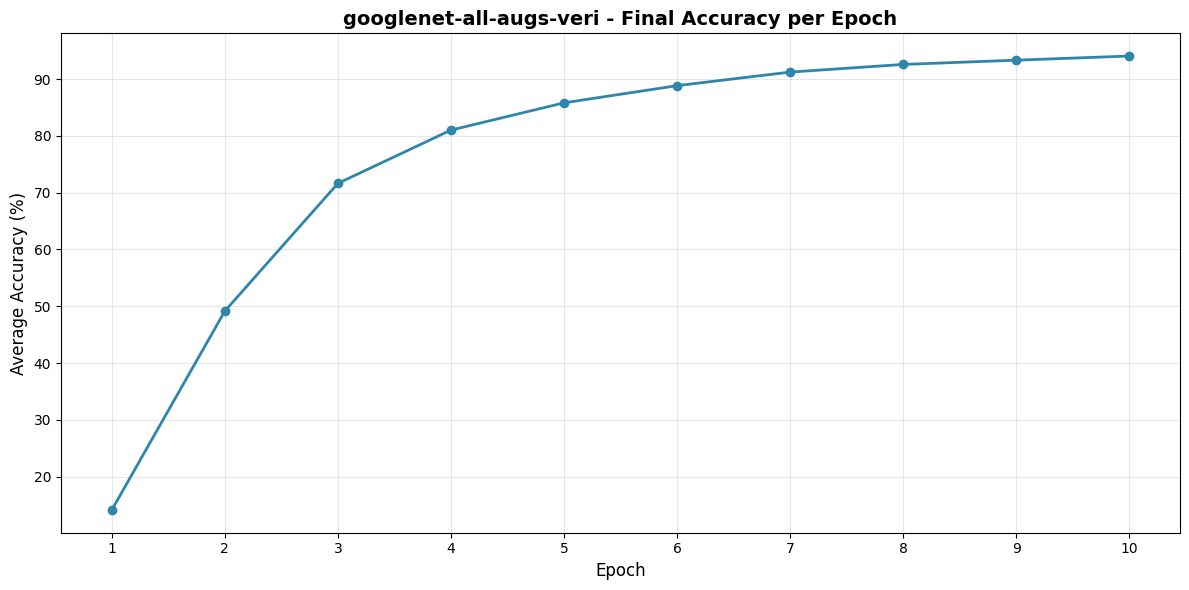


2. Batch-level instant accuracy:
Saved: figures\googlenet-all-augs-veri_batch_instant_accuracy.png


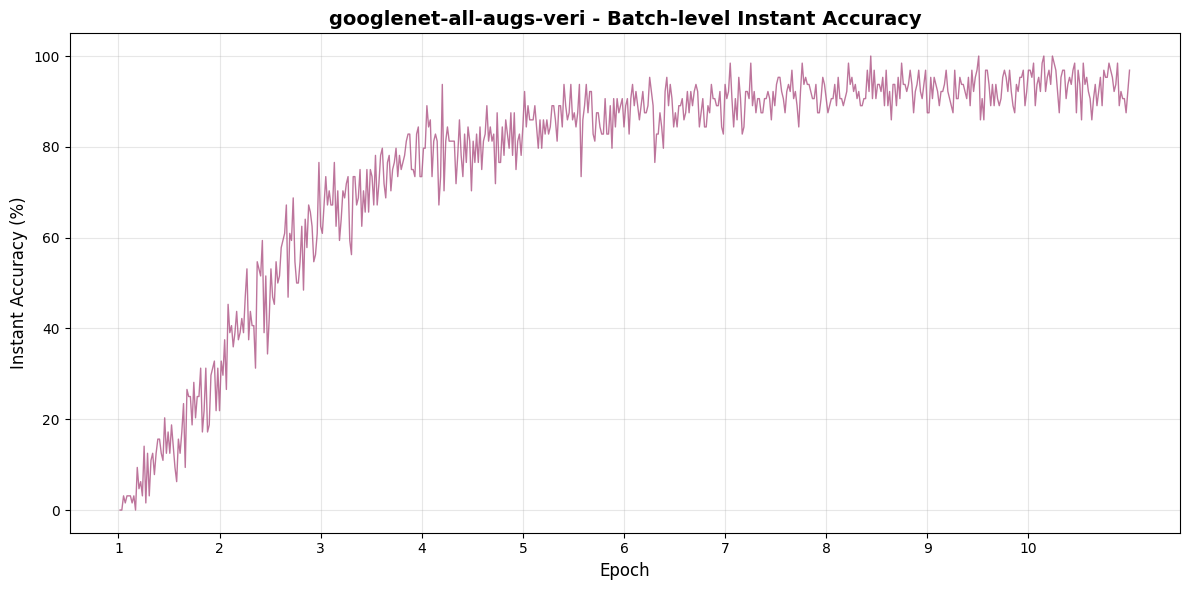


Processing: googlenet-color-aug-veri

1. Epoch-level accuracy (final acc_avg per epoch):
Saved: figures\googlenet-color-aug-veri_epoch_accuracy.png


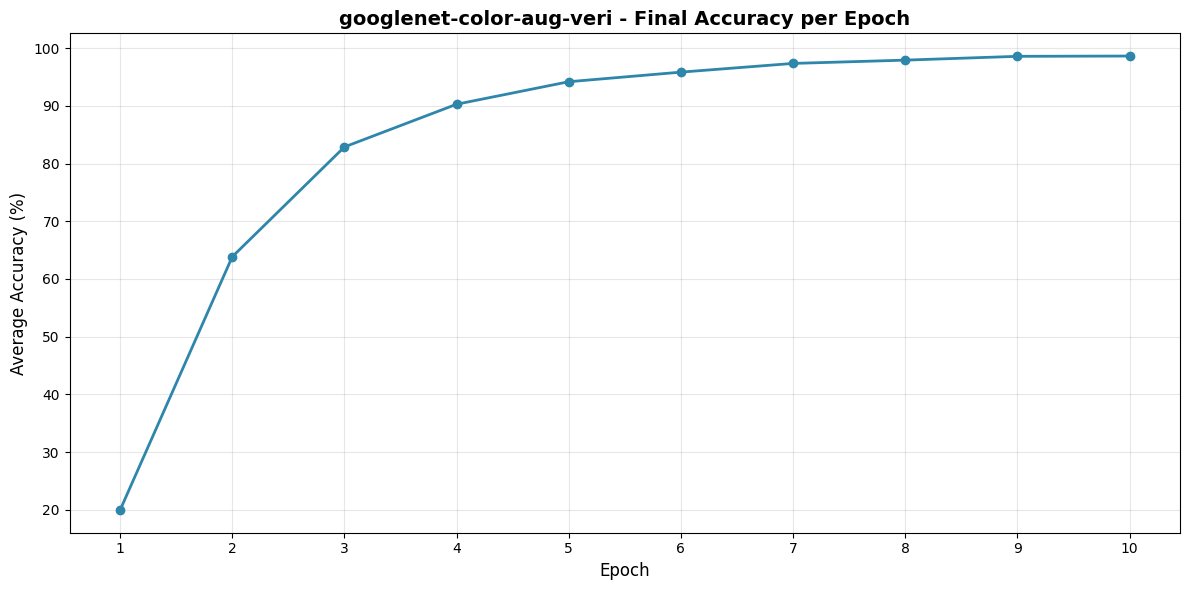


2. Batch-level instant accuracy:
Saved: figures\googlenet-color-aug-veri_batch_instant_accuracy.png


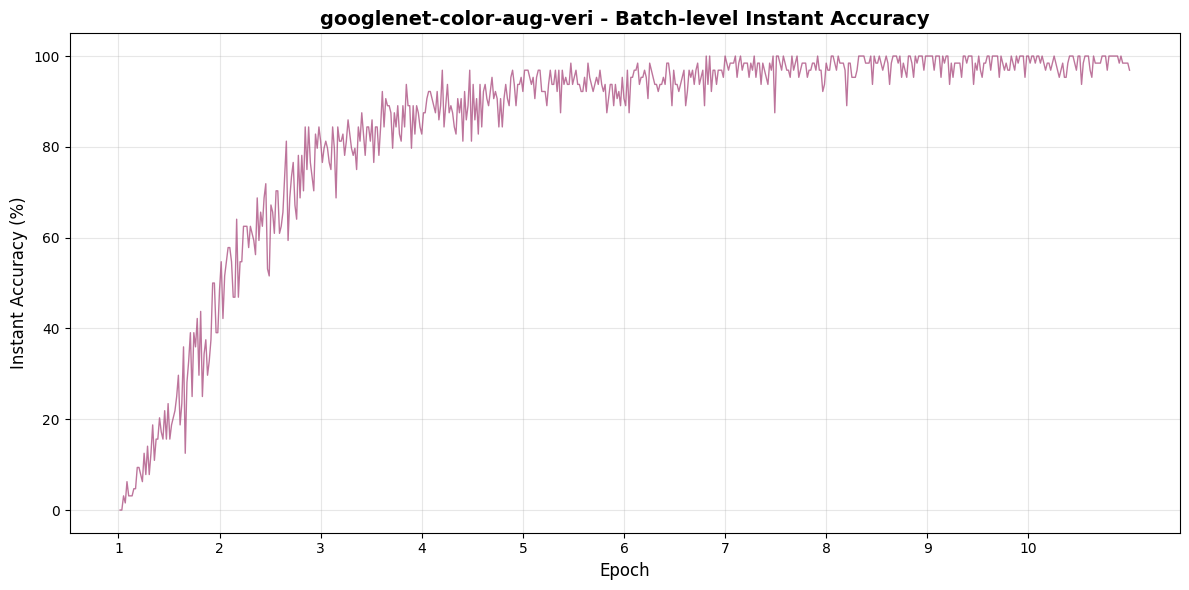


Processing: googlenet-color-jitter-veri

1. Epoch-level accuracy (final acc_avg per epoch):
Saved: figures\googlenet-color-jitter-veri_epoch_accuracy.png


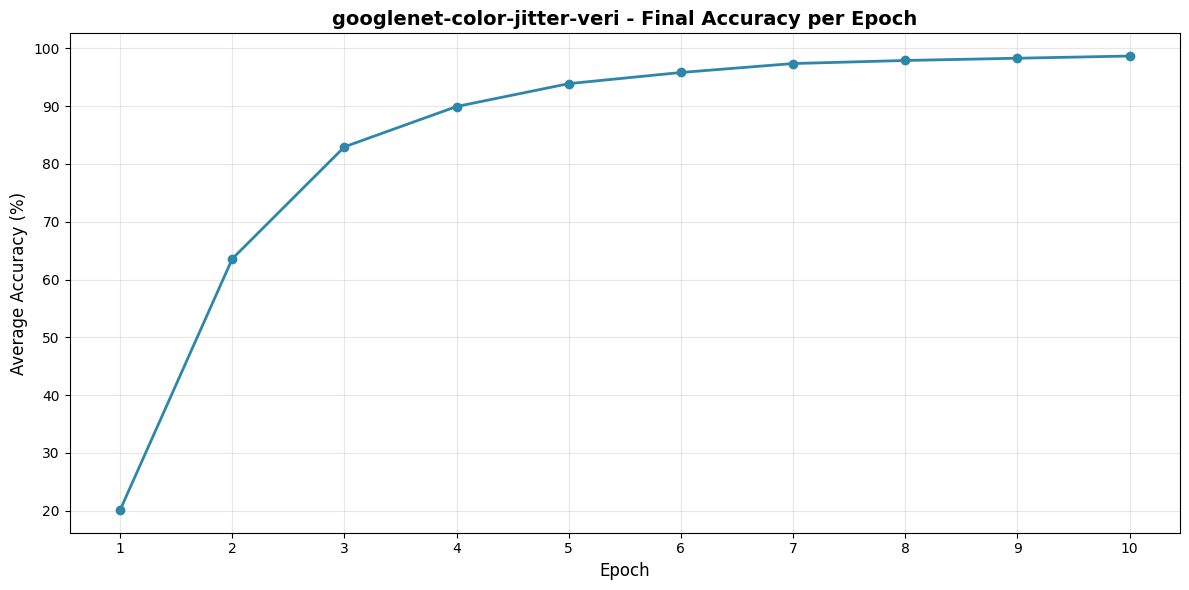


2. Batch-level instant accuracy:
Saved: figures\googlenet-color-jitter-veri_batch_instant_accuracy.png


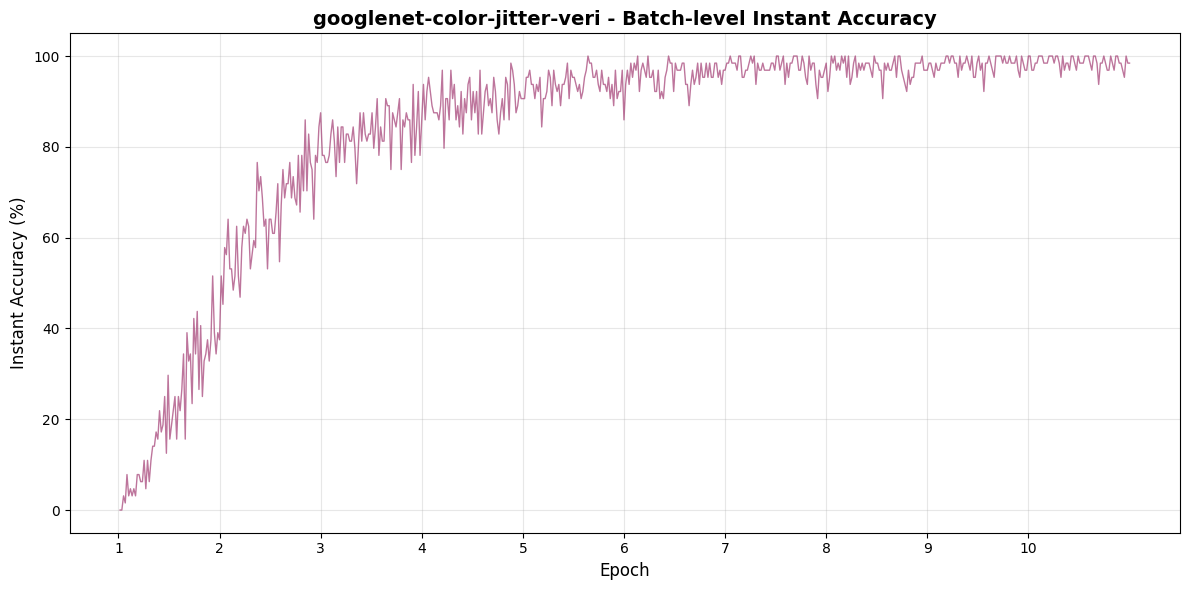


Processing: googlenet-random-erase-veri

1. Epoch-level accuracy (final acc_avg per epoch):
Saved: figures\googlenet-random-erase-veri_epoch_accuracy.png


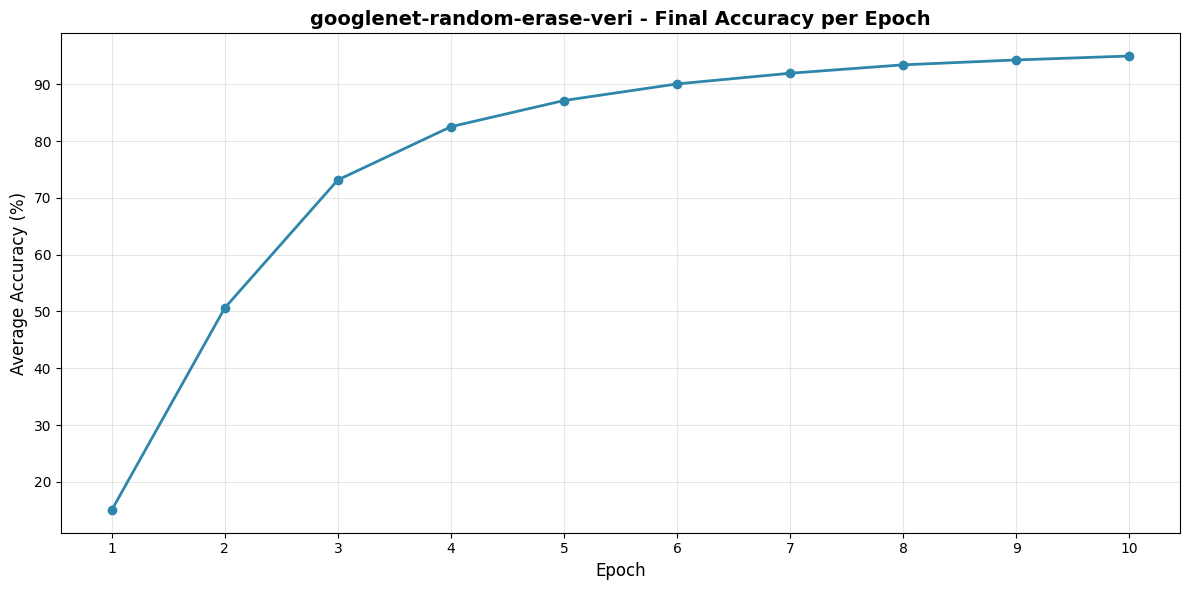


2. Batch-level instant accuracy:
Saved: figures\googlenet-random-erase-veri_batch_instant_accuracy.png


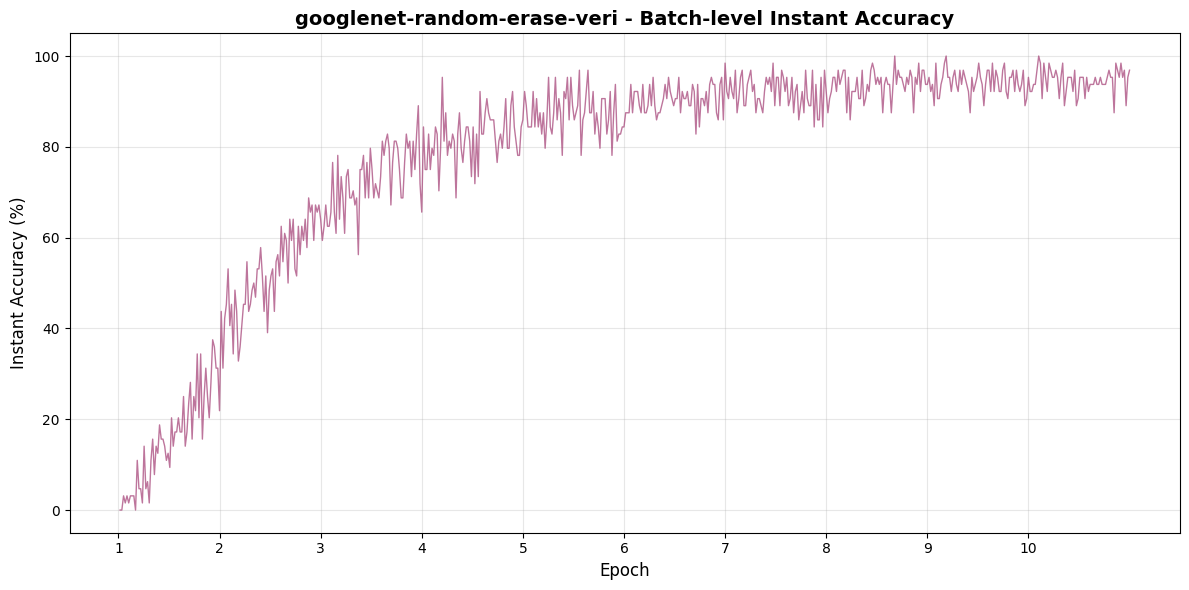


Processing: googlenet-veri

1. Epoch-level accuracy (final acc_avg per epoch):
Saved: figures\googlenet-veri_epoch_accuracy.png


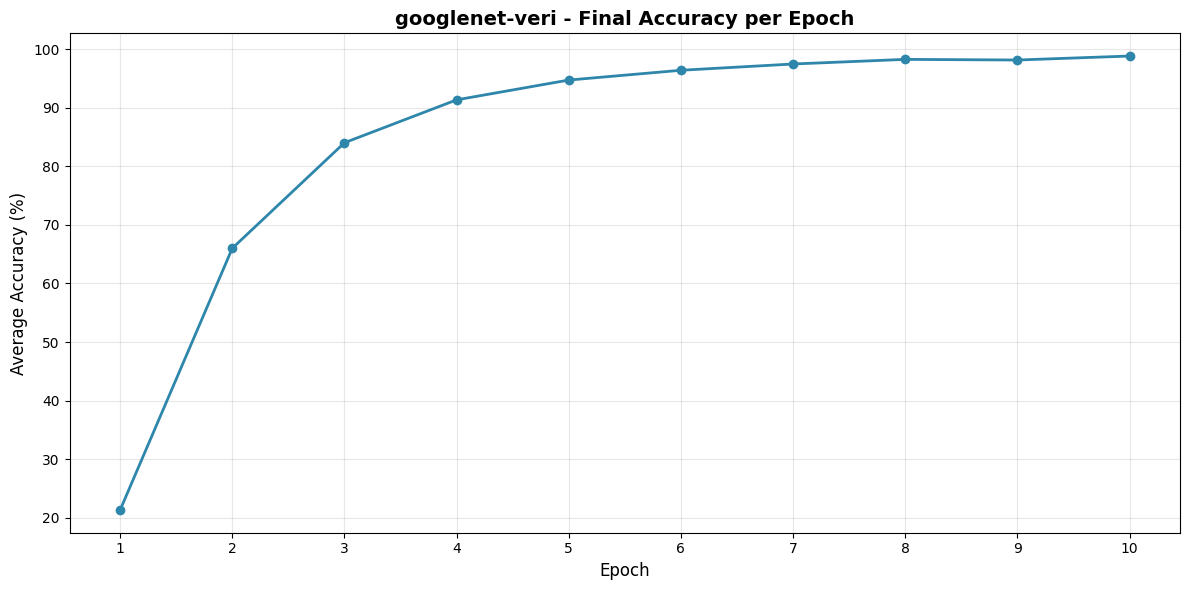


2. Batch-level instant accuracy:
Saved: figures\googlenet-veri_batch_instant_accuracy.png


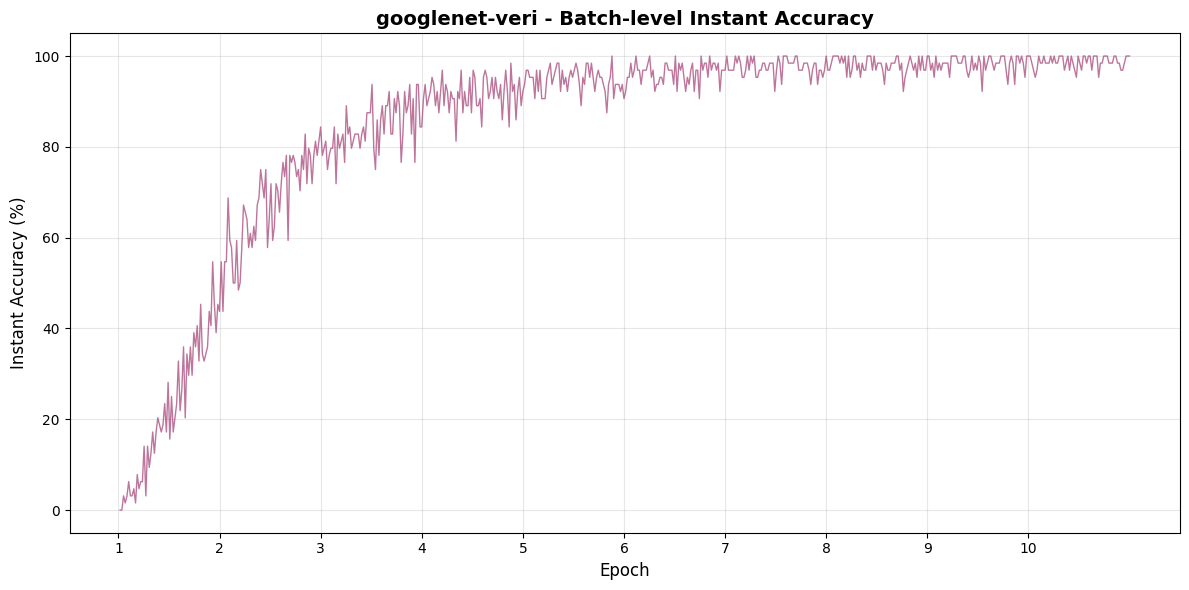


Processing: mobilenet_v3_small-veri

1. Epoch-level accuracy (final acc_avg per epoch):
Saved: figures\mobilenet_v3_small-veri_epoch_accuracy.png


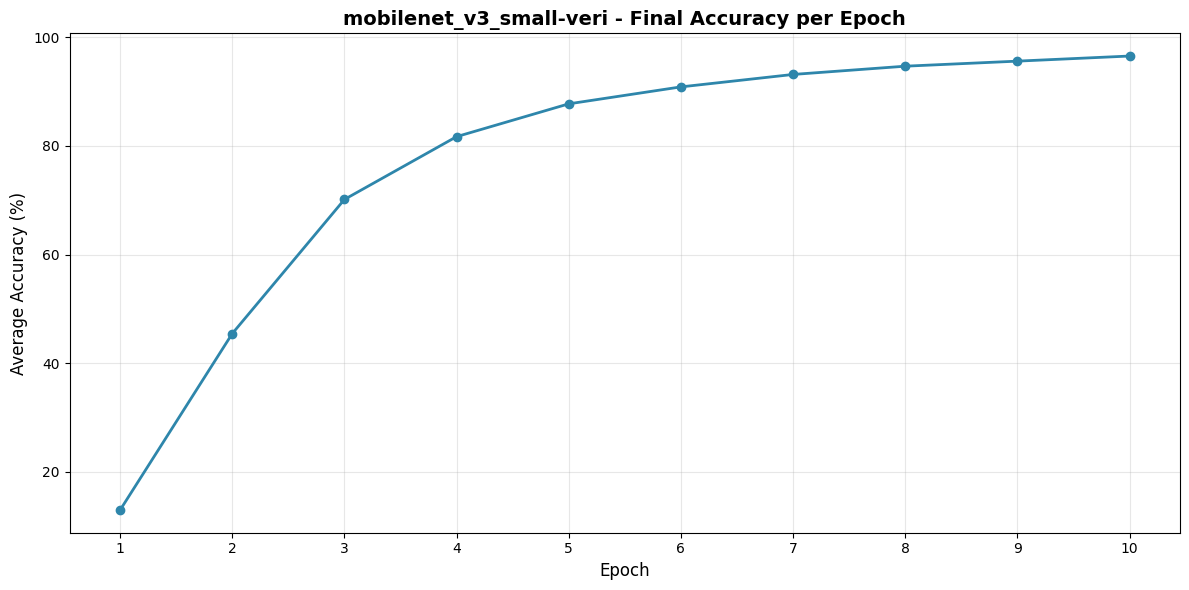


2. Batch-level instant accuracy:
Saved: figures\mobilenet_v3_small-veri_batch_instant_accuracy.png


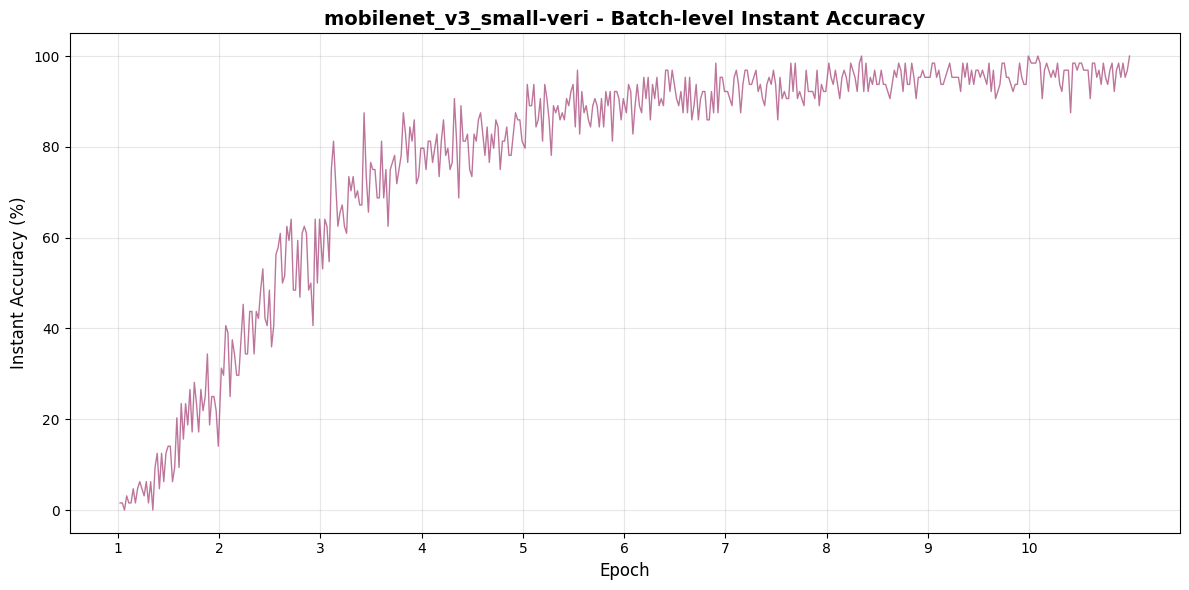


Processing: resnet50-veri

1. Epoch-level accuracy (final acc_avg per epoch):
Saved: figures\resnet50-veri_epoch_accuracy.png


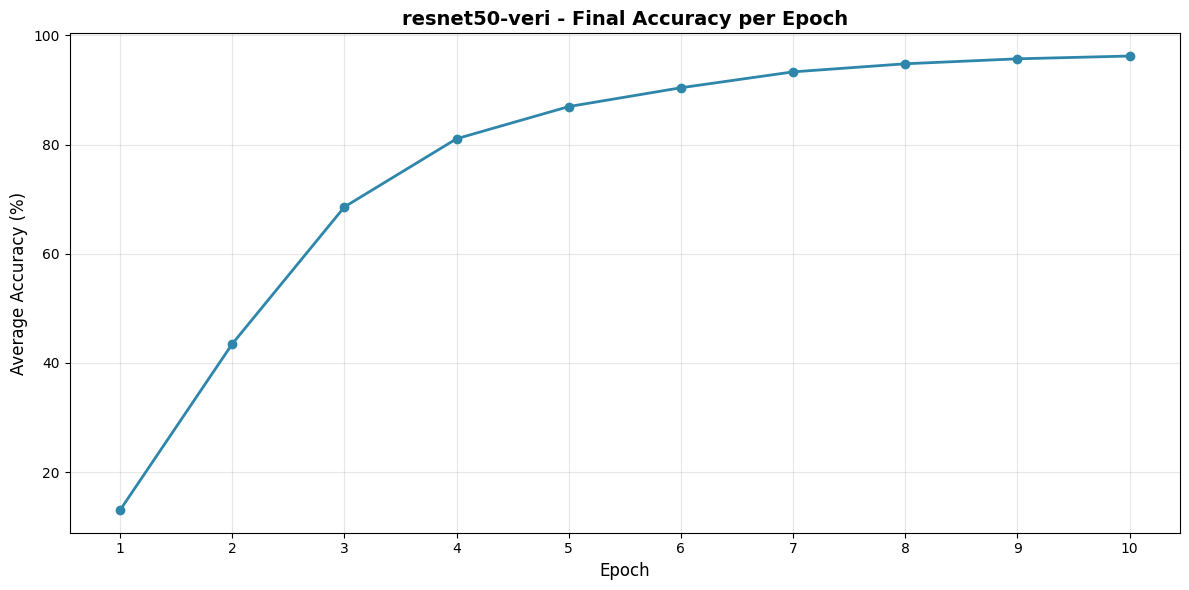


2. Batch-level instant accuracy:
Saved: figures\resnet50-veri_batch_instant_accuracy.png


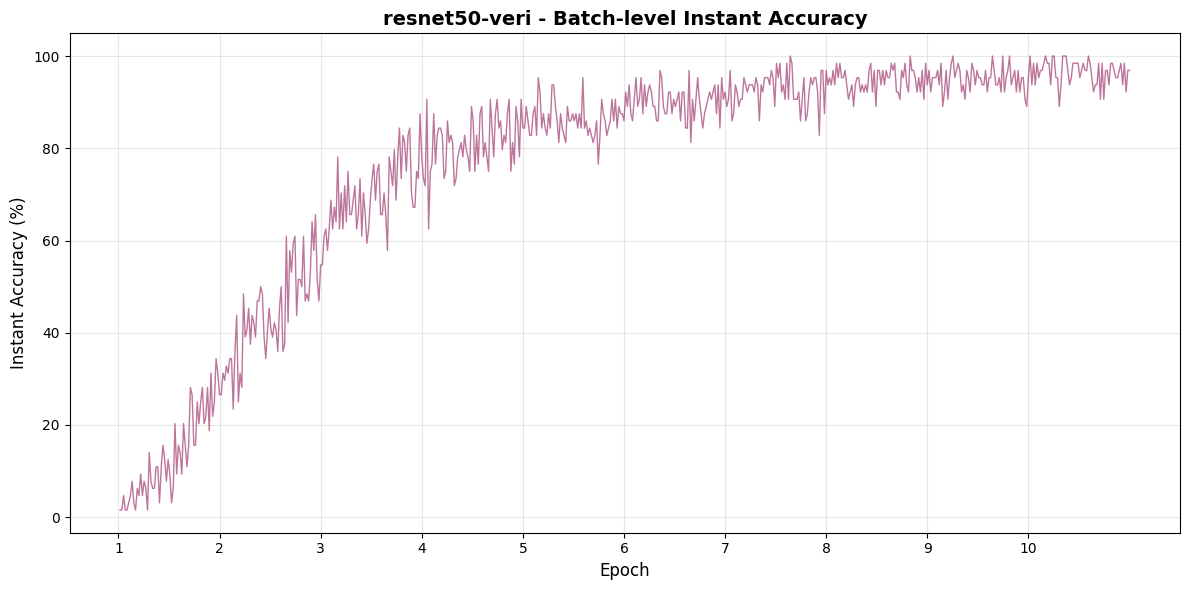


Processing: vgg16-veri

1. Epoch-level accuracy (final acc_avg per epoch):
Saved: figures\vgg16-veri_epoch_accuracy.png


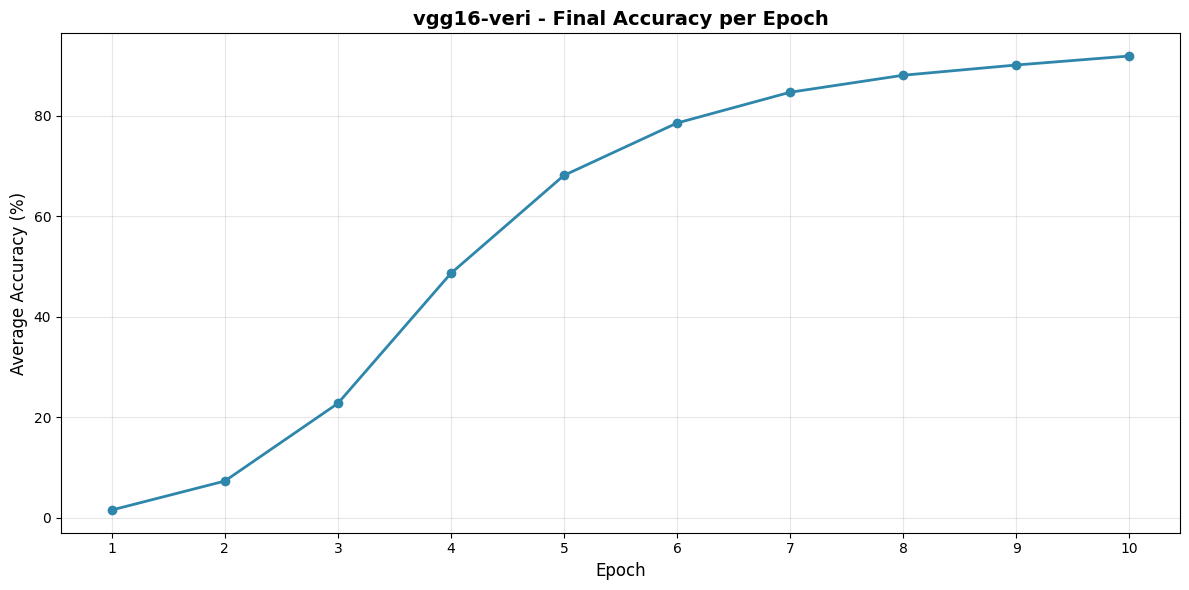


2. Batch-level instant accuracy:
Saved: figures\vgg16-veri_batch_instant_accuracy.png


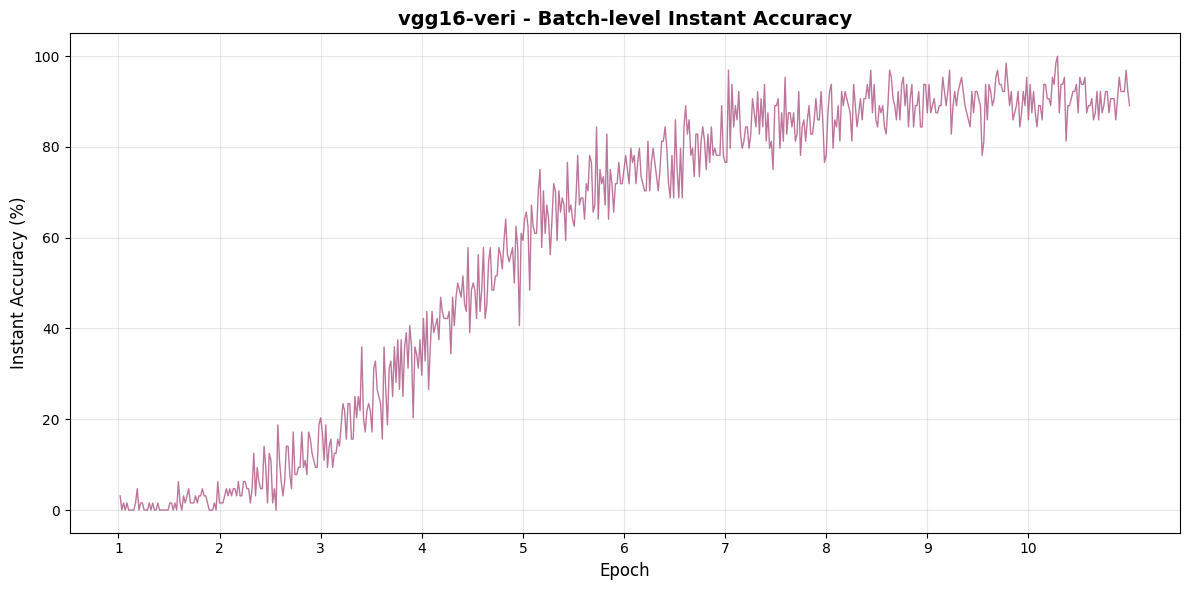


✓ Generated 16 plots in figures/ directory
  - 8 epoch-level plots
  - 8 batch-level plots


In [31]:
# Generate both plots for all experiments
for csv_file in training_csvs:
    # Extract experiment name from filename
    experiment_name = csv_file.stem.replace('_training', '')
    
    # Load CSV
    df = pd.read_csv(csv_file)
    
    print(f"\n{'='*60}")
    print(f"Processing: {experiment_name}")
    print(f"{'='*60}")
    
    # Plot 1: Final accuracy per epoch (clean view)
    print("\n1. Epoch-level accuracy (final acc_avg per epoch):")
    plot_epoch_accuracy(experiment_name, df)
    
    # Plot 2: Batch-level instant accuracy (detailed view)
    print("\n2. Batch-level instant accuracy:")
    plot_batch_instant_accuracy(experiment_name, df)

print(f"\n{'='*60}")
print(f"✓ Generated {len(training_csvs) * 2} plots in figures/ directory")
print(f"  - {len(training_csvs)} epoch-level plots")
print(f"  - {len(training_csvs)} batch-level plots")
print(f"{'='*60}")

## Test Results Summary

In [40]:
# Load all test results CSV files
test_csvs = list(results_dir.glob('*_test_results.csv'))

print(f"Found {len(test_csvs)} test result files:")
for csv_file in test_csvs:
    print(f"  - {csv_file.name}")

# Combine all test results into one dataframe
all_results = []

for csv_file in test_csvs:
    # Extract experiment name
    experiment_name = csv_file.stem.replace('_test_results', '')
    
    # Load CSV
    df = pd.read_csv(csv_file)
    
    # Add experiment name column
    df['experiment'] = experiment_name
    
    all_results.append(df)

# Concatenate all results
test_results_df = pd.concat(all_results, ignore_index=True)

print(f"\nCombined test results shape: {test_results_df.shape}")
test_results_df.head(10)

Found 8 test result files:
  - googlenet-all-augs-veri_test_results.csv
  - googlenet-color-aug-veri_test_results.csv
  - googlenet-color-jitter-veri_test_results.csv
  - googlenet-random-erase-veri_test_results.csv
  - googlenet-veri_test_results.csv
  - mobilenet_v3_small-veri_test_results.csv
  - resnet50-veri_test_results.csv
  - vgg16-veri_test_results.csv

Combined test results shape: (40, 3)


,metric,value,experiment
0,mAP,56.3,googlenet-all-augs-veri
1,Rank-1,86.1,googlenet-all-augs-veri
2,Rank-5,93.8,googlenet-all-augs-veri
3,Rank-10,96.5,googlenet-all-augs-veri
4,Rank-20,98.0,googlenet-all-augs-veri
5,mAP,54.9,googlenet-color-aug-veri
6,Rank-1,86.1,googlenet-color-aug-veri
7,Rank-5,92.1,googlenet-color-aug-veri
8,Rank-10,94.8,googlenet-color-aug-veri
9,Rank-20,97.5,googlenet-color-aug-veri


In [ ]:
# Create comprehensive summary table with mAP, Rank-1, and Rank-5
summary_metrics = test_results_df[test_results_df['metric'].isin(['mAP', 'Rank-1', 'Rank-5'])].copy()

# Pivot to get metrics as columns
summary_table = summary_metrics.pivot(index='experiment', columns='metric', values='value').reset_index()

# Reorder and rename columns explicitly
summary_table = summary_table[['experiment', 'mAP', 'Rank-1', 'Rank-5']]
summary_table.columns = ['Experiment', 'mAP (%)', 'Rank-1 (%)', 'Rank-5 (%)']

# Sort by mAP descending
summary_table = summary_table.sort_values('mAP (%)', ascending=False).reset_index(drop=True)

print("Test Results Summary Table:")
print("="*60)
summary_table

## CMC Curve for Baseline Models

Saved: figures/cmc_curve_data_augmentation.png


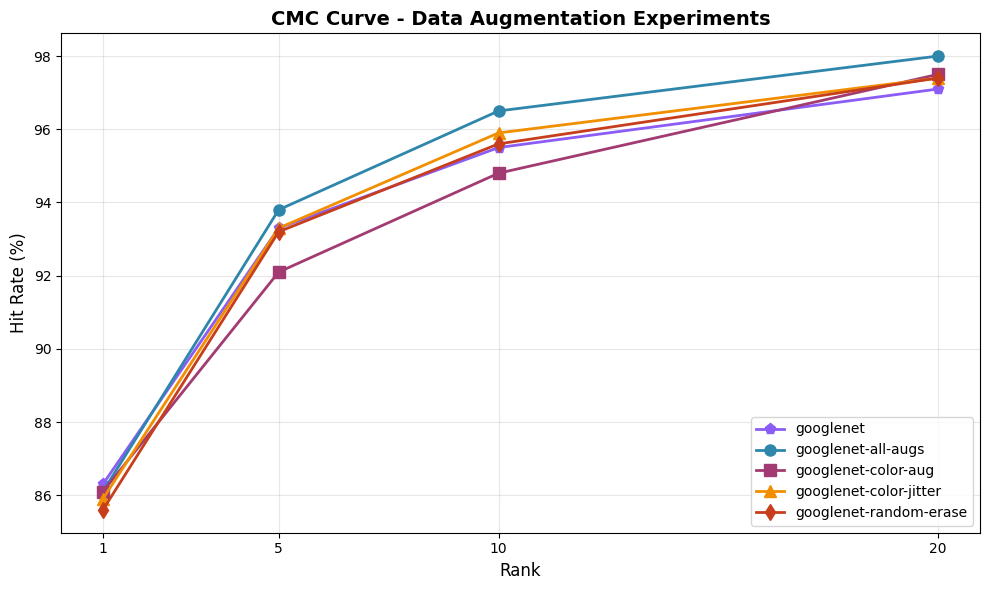

In [57]:
# Select baseline experiments for CMC curve
baseline_experiments = ['googlenet-veri', 'googlenet-all-augs-veri', 'googlenet-color-aug-veri', 'googlenet-color-jitter-veri', 'googlenet-random-erase-veri']

# Filter test results for these experiments and Rank metrics only
cmc_data = test_results_df[
    (test_results_df['experiment'].isin(baseline_experiments)) & 
    (test_results_df['metric'].str.startswith('Rank-'))
].copy()

# Extract rank number from metric name (e.g., "Rank-1" -> 1)
cmc_data['rank'] = cmc_data['metric'].str.extract(r'Rank-(\d+)').astype(int)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot CMC curve for each experiment with different colors and markers
styles = {
    'googlenet-veri': {'color': '#8B5CF6', 'marker': 'p'}, 
    'googlenet-all-augs-veri': {'color': '#2E86AB', 'marker': 'o'}, 
    'googlenet-color-aug-veri': {'color': '#A23B72', 'marker': 's'}, 
    'googlenet-color-jitter-veri': {'color': '#F18F01', 'marker': '^'}, 
    'googlenet-random-erase-veri': {'color': '#C73E1D', 'marker': 'd'}
}

for experiment in baseline_experiments:
    exp_data = cmc_data[cmc_data['experiment'] == experiment].sort_values('rank')
    # Remove '-veri' from label
    label = experiment.replace('-veri', '')
    ax.plot(exp_data['rank'], exp_data['value'], 
            marker=styles[experiment]['marker'], linewidth=2, markersize=8,
            color=styles[experiment]['color'], label=label)

# Formatting
ax.set_xlabel('Rank', fontsize=12)
ax.set_ylabel('Hit Rate (%)', fontsize=12)
ax.set_title('CMC Curve - Data Augmentation Experiments', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(cmc_data['rank'].unique())

plt.tight_layout()

# Save figure
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/cmc_curve_data_augmentation.png', dpi=300, bbox_inches='tight')
print("Saved: figures/cmc_curve_data_augmentation.png")

plt.show()

## Training Accuracy Comparison - Baseline Models

Saved: figures/training_accuracy_comparison_data_augmentation.png


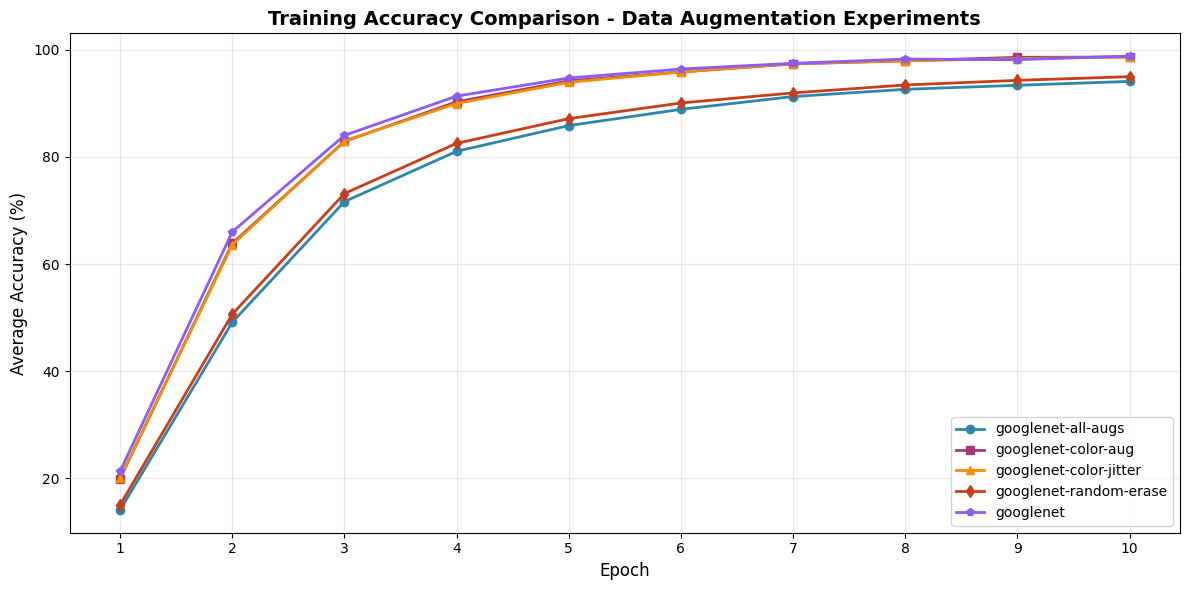

In [58]:
# Compare final epoch accuracy for data augmentation experiments
baseline_experiments = ['googlenet-veri', 'googlenet-all-augs-veri', 'googlenet-color-aug-veri', 'googlenet-color-jitter-veri', 'googlenet-random-erase-veri']

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot styles matching CMC curve
styles = {
    'googlenet-veri': {'color': '#8B5CF6', 'marker': 'p'},  # Purple with pentagon marker
    'googlenet-all-augs-veri': {'color': '#2E86AB', 'marker': 'o'}, 
    'googlenet-color-aug-veri': {'color': '#A23B72', 'marker': 's'}, 
    'googlenet-color-jitter-veri': {'color': '#F18F01', 'marker': '^'}, 
    'googlenet-random-erase-veri': {'color': '#C73E1D', 'marker': 'd'}
}

# Plot each model
for csv_file in training_csvs:
    experiment_name = csv_file.stem.replace('_training', '')
    
    if experiment_name in baseline_experiments:
        # Load CSV
        df = pd.read_csv(csv_file)
        
        # Get final acc_avg per epoch
        epoch_final = df.groupby('epoch').last().reset_index()
        
        # Clean label
        label = experiment_name.replace('-veri', '')
        
        # Plot
        ax.plot(epoch_final['epoch'], epoch_final['acc_avg'], 
                linewidth=2, marker=styles[experiment_name]['marker'], markersize=6,
                color=styles[experiment_name]['color'], label=label)

# Formatting
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Average Accuracy (%)', fontsize=12)
ax.set_title('Training Accuracy Comparison - Data Augmentation Experiments', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(epoch_final['epoch'])

plt.tight_layout()

# Save figure
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/training_accuracy_comparison_data_augmentation.png', dpi=300, bbox_inches='tight')
print("Saved: figures/training_accuracy_comparison_data_augmentation.png")

plt.show()

## Training Loss Comparison - Baseline Models

Saved: figures/training_loss_comparison_data_augmentation.png


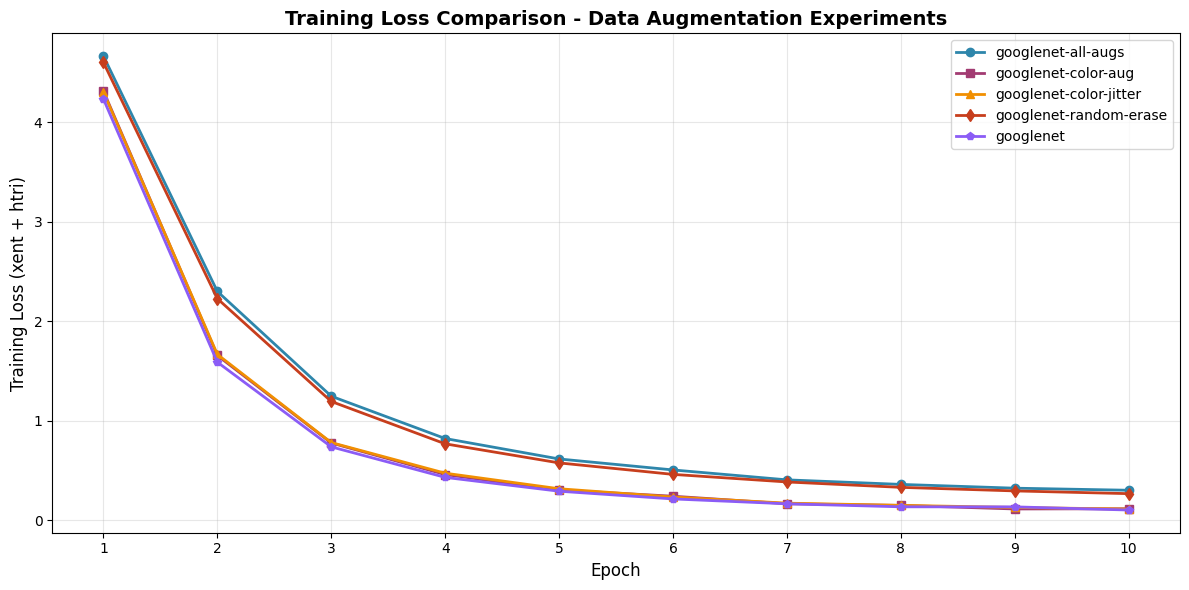

In [59]:
# Compare training loss for baseline models
baseline_models = ['googlenet-veri', 'googlenet-all-augs-veri', 'googlenet-color-aug-veri', 'googlenet-color-jitter-veri', 'googlenet-random-erase-veri']

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot styles matching other charts
styles = {
    'googlenet-veri': {'color': '#8B5CF6', 'marker': 'p'},  # Purple with pentagon marker
    'googlenet-all-augs-veri': {'color': '#2E86AB', 'marker': 'o'}, 
    'googlenet-color-aug-veri': {'color': '#A23B72', 'marker': 's'}, 
    'googlenet-color-jitter-veri': {'color': '#F18F01', 'marker': '^'}, 
    'googlenet-random-erase-veri': {'color': '#C73E1D', 'marker': 'd'}
}

# Plot each model
for csv_file in training_csvs:
    experiment_name = csv_file.stem.replace('_training', '')
    
    if experiment_name in baseline_models:
        # Load CSV
        df = pd.read_csv(csv_file)
        
        # Calculate combined loss (xent_avg + htri_avg)
        df['total_loss'] = df['xent_avg'] + df['htri_avg']
        
        # Get final loss per epoch
        epoch_final = df.groupby('epoch').last().reset_index()
        
        # Clean label
        label = experiment_name.replace('-veri', '')
        
        # Plot
        ax.plot(epoch_final['epoch'], epoch_final['total_loss'], 
                linewidth=2, marker=styles[experiment_name]['marker'], markersize=6,
                color=styles[experiment_name]['color'], label=label)

# Formatting
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Loss (xent + htri)', fontsize=12)
ax.set_title('Training Loss Comparison - Data Augmentation Experiments', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(epoch_final['epoch'])

plt.tight_layout()

# Save figure
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/training_loss_comparison_data_augmentation.png', dpi=300, bbox_inches='tight')
print("Saved: figures/training_loss_comparison_data_augmentation.png")

plt.show()